### **0. Data Ingestion, Preliminary Data Analysis**

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile
import pandas as pd
import numpy as np
import os


In [10]:
zip_path = r"C:\Users\User\Desktop\ABEOKUTA\AI_Engineer\DataAndData_analysis\DataAndData_analysis\Task_folder\pandas\exploratorytask\wine+quality (1).zip"
with zipfile.ZipFile(zip_path,'r') as Zip_ref:
    Zip_ref.printdir()

File Name                                             Modified             Size
winequality-red.csv                            2023-05-22 22:24:00        84199
winequality-white.csv                          2023-05-22 22:24:00       264426
winequality.names                              2023-05-22 22:24:00         3305


In [11]:
with zipfile.ZipFile(zip_path) as z:
    with z.open('winequality-white.csv') as f:
        white_wine= pd.read_csv(f,sep=";")

In [12]:
white_wine.head(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6


In [13]:
white_wine.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [14]:
white_wine.columns=white_wine.columns.str.replace(" ","_")

In [15]:
white_wine

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [16]:
white_wine.dtypes

fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

In [17]:
# lets pick out the numerical columns and get the descriptions
white_wine.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,4898.0,6.854788,0.843868,3.80000,6.300000,6.80000,7.3000,14.20000
volatile_acidity,4898.0,0.278241,0.100795,0.08000,0.210000,0.26000,0.3200,1.10000
citric_acid,4898.0,0.334192,0.121020,0.00000,0.270000,0.32000,0.3900,1.66000
residual_sugar,4898.0,6.391415,5.072058,0.60000,1.700000,5.20000,9.9000,65.80000
chlorides,4898.0,0.045772,0.021848,0.00900,0.036000,0.04300,0.0500,0.34600
free_sulfur_dioxide,4898.0,35.308085,17.007137,2.00000,23.000000,34.00000,46.0000,289.00000
total_sulfur_dioxide,4898.0,138.360657,42.498065,9.00000,108.000000,134.00000,167.0000,440.00000
density,4898.0,0.994027,0.002991,0.98711,0.991723,0.99374,0.9961,1.03898
pH,4898.0,3.188267,0.151001,2.72000,3.090000,3.18000,3.2800,3.82000
sulphates,4898.0,0.489847,0.114126,0.22000,0.410000,0.47000,0.5500,1.08000


In [18]:
white_wine.quality.unique()

array([6, 5, 7, 8, 4, 3, 9])

In [19]:
def map_quality_category(x):
    if x <= 4:
        return 'Low'
    elif x <= 6 :
        return 'Medium'
    else:
        return 'High'
    
# lets apply  our function 
white_wine['quality_label']= white_wine['quality'].apply(map_quality_category)

In [20]:

white_wine.head(3)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,quality_label
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,Medium
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,Medium
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,Medium


In [21]:
# lets make a copy of our data 
df = white_wine.copy()

## **1. Univariate analysis**

In [22]:
def univariate_numeric(df,column):
    print(df[column].describe().to_frame())
    print(f"\nSkewness: {df[column].skew():.3f}")
    print(f"Kurtosis: {df[column].kurt():.3f}")

    plt.figure(figsize=(12,4))

    # Histogram + KDE 
    plt.subplot(1,2,1)
    sns.histplot(df[column],kde=True,bins=30,color='teal')
    plt.title(f'\n Distribution of {column}', fontsize=13)
    plt.xlabel(column)
    plt.ylabel('Frequency')

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(df[column],color='teal')
    plt.title(f'\n Boxplot of {column}', fontsize=13)

    plt.tight_layout()
    plt.show()

    # Optional note on transformation 
    if abs(df[column].skew()) > 1:
        print(f'\n {column} is highly skewed. Consider log or Box-Cox transformation')
    elif abs(df[column].skew()) >0.5:
        print(f'{column} is moderately skewed.')
    else: 
        print(f'{column} is fairly symmetric.')

fixed_acidity
6.80     6.288281
6.60     5.920784
6.40     5.716619
6.90     4.920376
6.70     4.818293
           ...   
14.20    0.020416
4.50     0.020416
6.45     0.020416
3.80     0.020416
3.90     0.020416
Name: proportion, Length: 68, dtype: float64
       fixed_acidity
count    4898.000000
mean        6.854788
std         0.843868
min         3.800000
25%         6.300000
50%         6.800000
75%         7.300000
max        14.200000

Skewness: 0.648
Kurtosis: 2.172


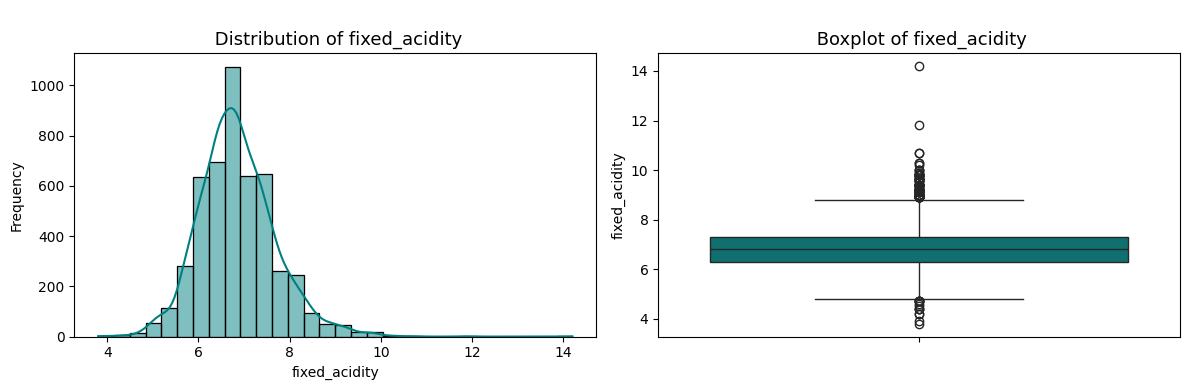

fixed_acidity is moderately skewed.
volatile_acidity
0.280    5.369539
0.240    5.165374
0.260    4.899959
0.250    4.716211
0.220    4.675378
           ...   
1.100    0.020416
0.090    0.020416
0.785    0.020416
0.405    0.020416
0.355    0.020416
Name: proportion, Length: 125, dtype: float64
       volatile_acidity
count       4898.000000
mean           0.278241
std            0.100795
min            0.080000
25%            0.210000
50%            0.260000
75%            0.320000
max            1.100000

Skewness: 1.577
Kurtosis: 5.092


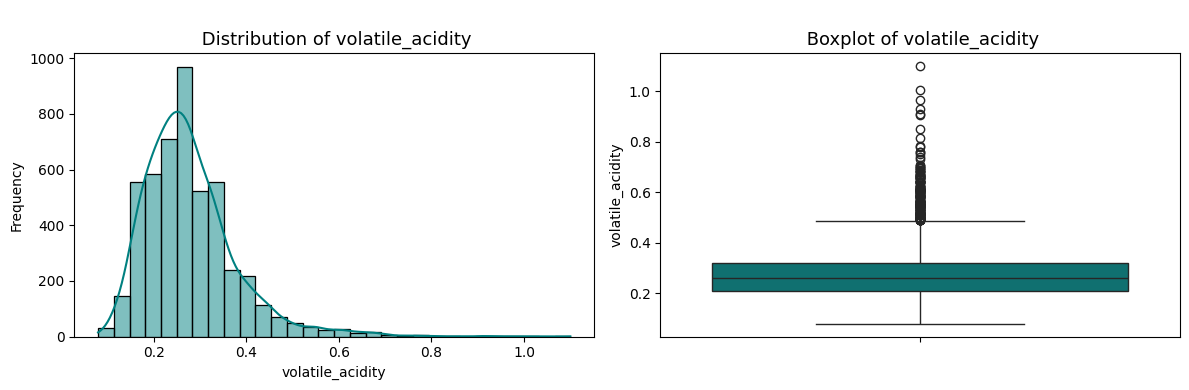


 volatile_acidity is highly skewed. Consider log or Box-Cox transformation
citric_acid
0.30    6.267864
0.28    5.757452
0.32    5.247040
0.34    4.593712
0.29    4.552879
          ...   
1.66    0.020416
0.99    0.020416
1.23    0.020416
0.86    0.020416
0.11    0.020416
Name: proportion, Length: 87, dtype: float64
       citric_acid
count  4898.000000
mean      0.334192
std       0.121020
min       0.000000
25%       0.270000
50%       0.320000
75%       0.390000
max       1.660000

Skewness: 1.282
Kurtosis: 6.175


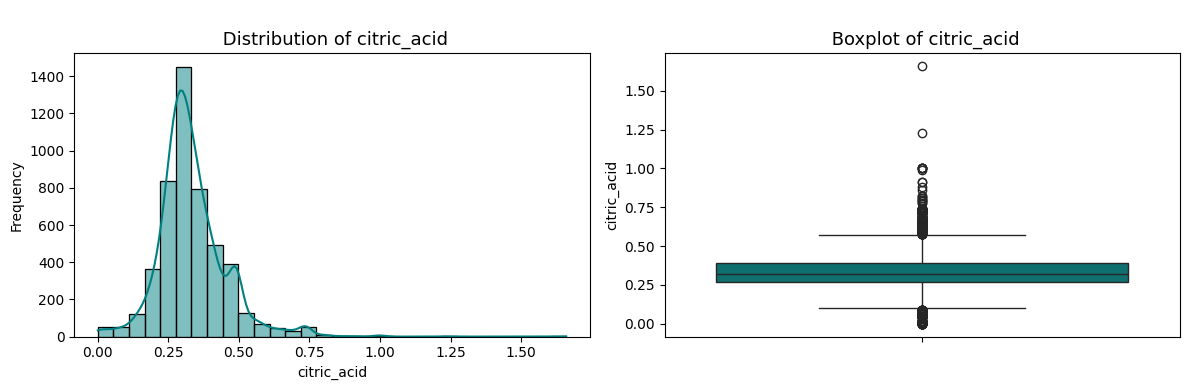


 citric_acid is highly skewed. Consider log or Box-Cox transformation
residual_sugar
1.20     3.817885
1.40     3.756635
1.60     3.368722
1.30     3.001225
1.10     2.980808
           ...   
2.65     0.020416
2.35     0.020416
4.35     0.020416
8.55     0.020416
18.40    0.020416
Name: proportion, Length: 310, dtype: float64
       residual_sugar
count     4898.000000
mean         6.391415
std          5.072058
min          0.600000
25%          1.700000
50%          5.200000
75%          9.900000
max         65.800000

Skewness: 1.077
Kurtosis: 3.470


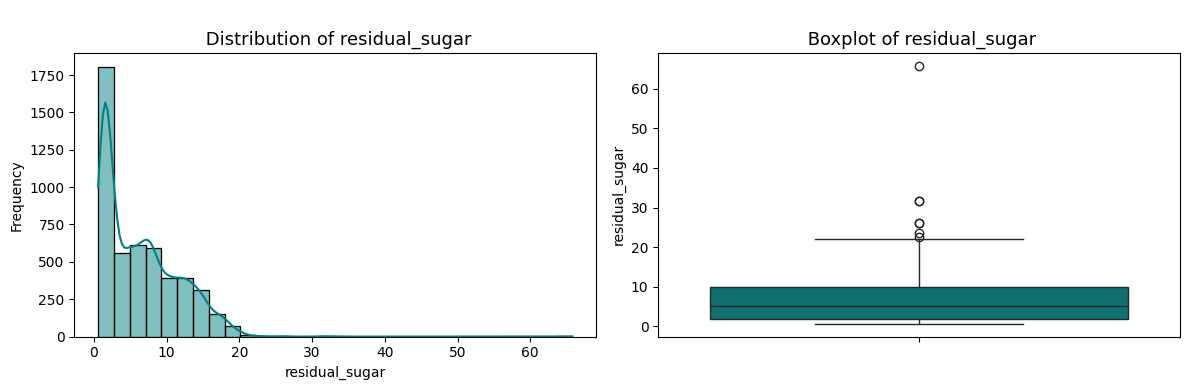


 residual_sugar is highly skewed. Consider log or Box-Cox transformation
chlorides
0.044    4.103716
0.036    4.083299
0.042    3.756635
0.040    3.715802
0.046    3.695386
           ...   
0.209    0.020416
0.271    0.020416
0.120    0.020416
0.212    0.020416
0.136    0.020416
Name: proportion, Length: 160, dtype: float64
         chlorides
count  4898.000000
mean      0.045772
std       0.021848
min       0.009000
25%       0.036000
50%       0.043000
75%       0.050000
max       0.346000

Skewness: 5.023
Kurtosis: 37.565


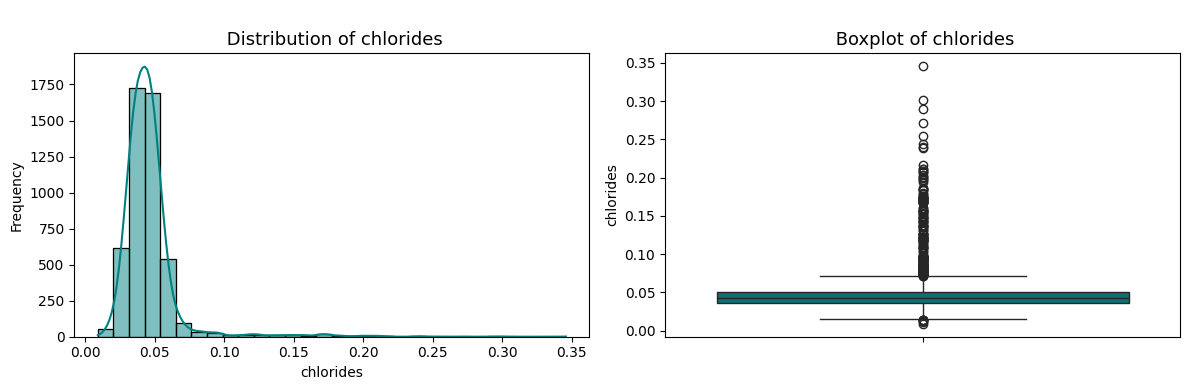


 chlorides is highly skewed. Consider log or Box-Cox transformation
free_sulfur_dioxide
29.0     3.266639
31.0     2.694978
35.0     2.633728
26.0     2.633728
34.0     2.613312
           ...   
70.5     0.020416
28.5     0.020416
43.5     0.020416
289.0    0.020416
97.0     0.020416
Name: proportion, Length: 132, dtype: float64
       free_sulfur_dioxide
count          4898.000000
mean             35.308085
std              17.007137
min               2.000000
25%              23.000000
50%              34.000000
75%              46.000000
max             289.000000

Skewness: 1.407
Kurtosis: 11.466


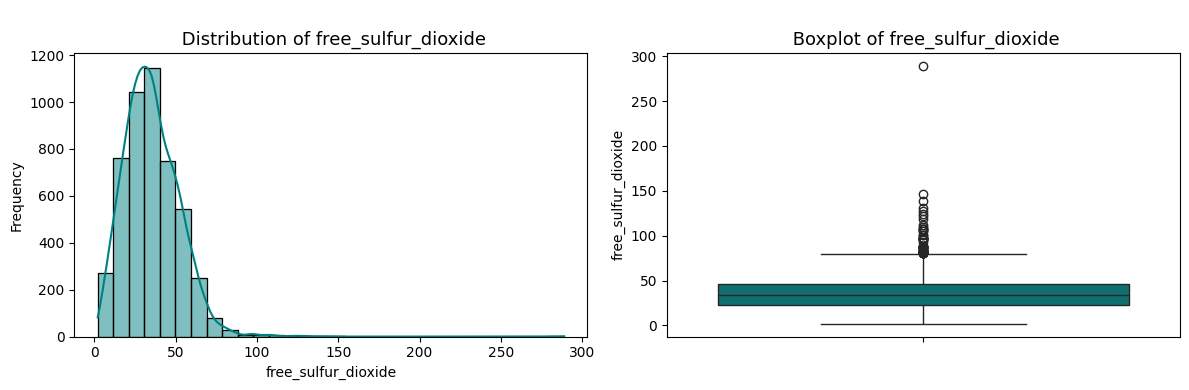


 free_sulfur_dioxide is highly skewed. Consider log or Box-Cox transformation
total_sulfur_dioxide
111.0    1.408738
113.0    1.245406
117.0    1.163740
118.0    1.122907
114.0    1.102491
           ...   
176.5    0.020416
259.0    0.020416
164.5    0.020416
440.0    0.020416
44.0     0.020416
Name: proportion, Length: 251, dtype: float64
       total_sulfur_dioxide
count           4898.000000
mean             138.360657
std               42.498065
min                9.000000
25%              108.000000
50%              134.000000
75%              167.000000
max              440.000000

Skewness: 0.391
Kurtosis: 0.572


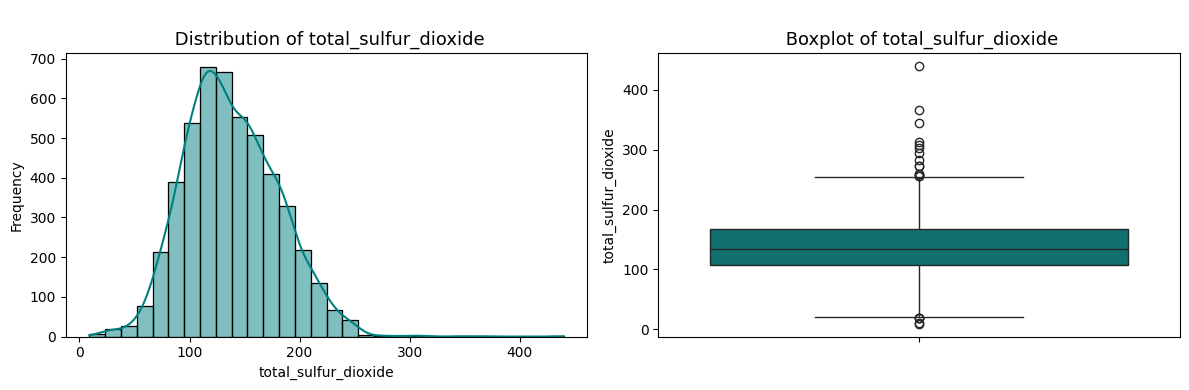

total_sulfur_dioxide is fairly symmetric.
density
0.992000    1.306656
0.992800    1.245406
0.993200    1.082074
0.993000    1.061658
0.993400    1.020825
              ...   
0.998450    0.020416
0.998365    0.020416
0.989410    0.020416
0.997880    0.020416
0.994330    0.020416
Name: proportion, Length: 890, dtype: float64
           density
count  4898.000000
mean      0.994027
std       0.002991
min       0.987110
25%       0.991723
50%       0.993740
75%       0.996100
max       1.038980

Skewness: 0.978
Kurtosis: 9.794


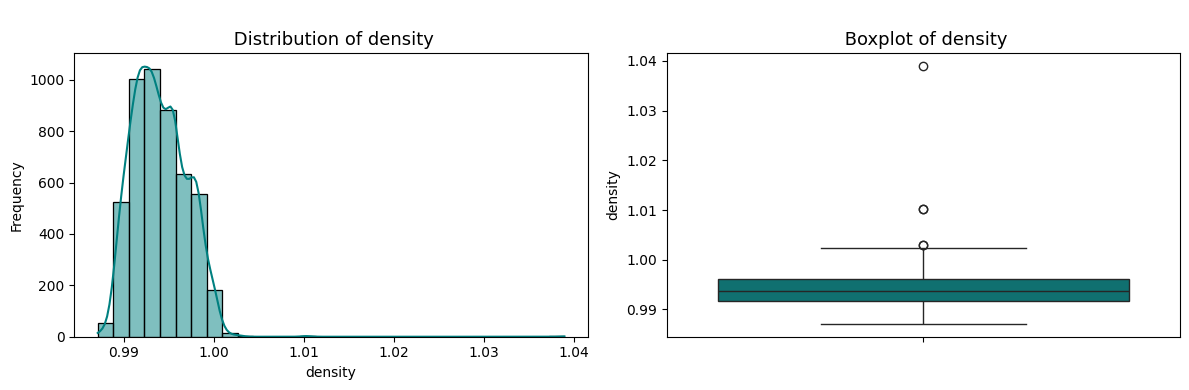

density is moderately skewed.
pH
3.14    3.511637
3.16    3.348305
3.22    2.980808
3.19    2.960392
3.18    2.817477
          ...   
3.79    0.020416
2.84    0.020416
3.70    0.020416
2.82    0.020416
3.67    0.020416
Name: proportion, Length: 103, dtype: float64
                pH
count  4898.000000
mean      3.188267
std       0.151001
min       2.720000
25%       3.090000
50%       3.180000
75%       3.280000
max       3.820000

Skewness: 0.458
Kurtosis: 0.531


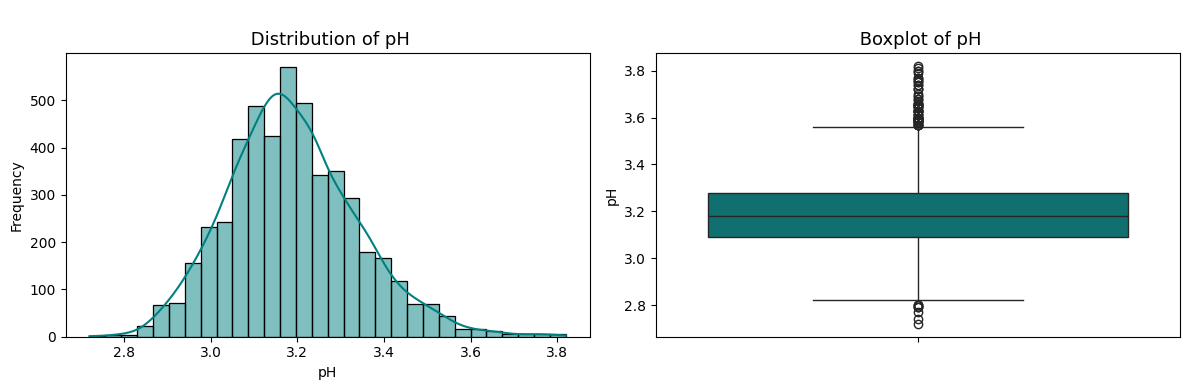

pH is fairly symmetric.
sulphates
0.50    5.083708
0.46    4.593712
0.44    4.409963
0.38    4.369130
0.42    3.695386
          ...   
0.89    0.020416
0.22    0.020416
0.23    0.020416
1.01    0.020416
1.08    0.020416
Name: proportion, Length: 79, dtype: float64
         sulphates
count  4898.000000
mean      0.489847
std       0.114126
min       0.220000
25%       0.410000
50%       0.470000
75%       0.550000
max       1.080000

Skewness: 0.977
Kurtosis: 1.591


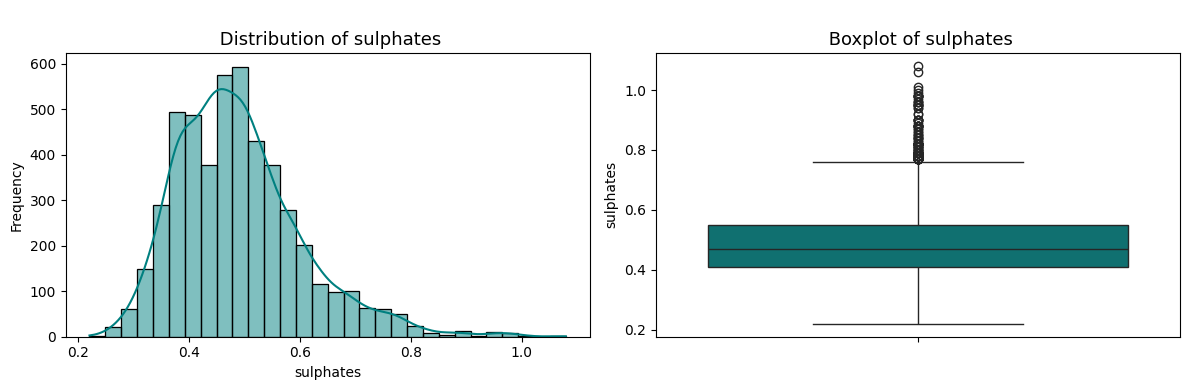

sulphates is moderately skewed.
alcohol
9.400000     4.675378
9.500000     4.654961
9.200000     4.062883
9.000000     3.777052
10.000000    3.307472
               ...   
11.950000    0.020416
12.066667    0.020416
11.550000    0.020416
9.633333     0.020416
12.050000    0.020416
Name: proportion, Length: 103, dtype: float64
           alcohol
count  4898.000000
mean     10.514267
std       1.230621
min       8.000000
25%       9.500000
50%      10.400000
75%      11.400000
max      14.200000

Skewness: 0.487
Kurtosis: -0.698


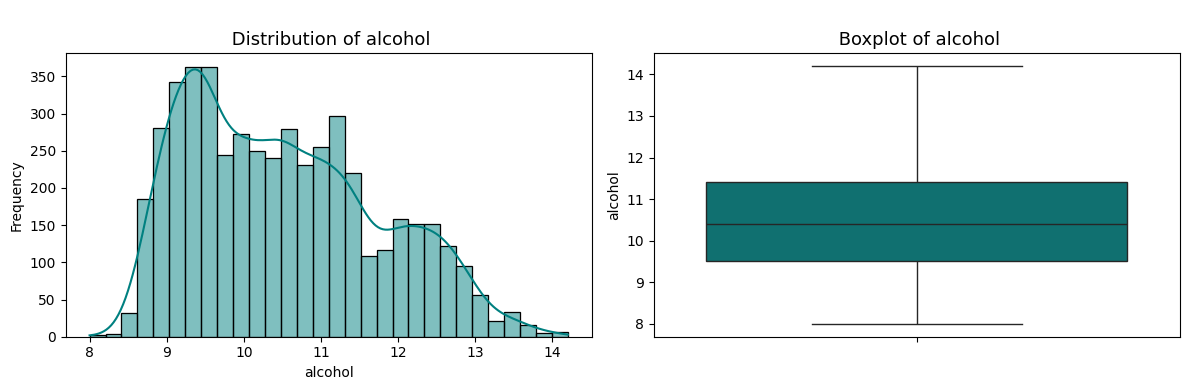

alcohol is fairly symmetric.
quality
6    44.875459
5    29.746835
7    17.966517
8     3.572887
4     3.327889
3     0.408330
9     0.102082
Name: proportion, dtype: float64
           quality
count  4898.000000
mean      5.877909
std       0.885639
min       3.000000
25%       5.000000
50%       6.000000
75%       6.000000
max       9.000000

Skewness: 0.156
Kurtosis: 0.217


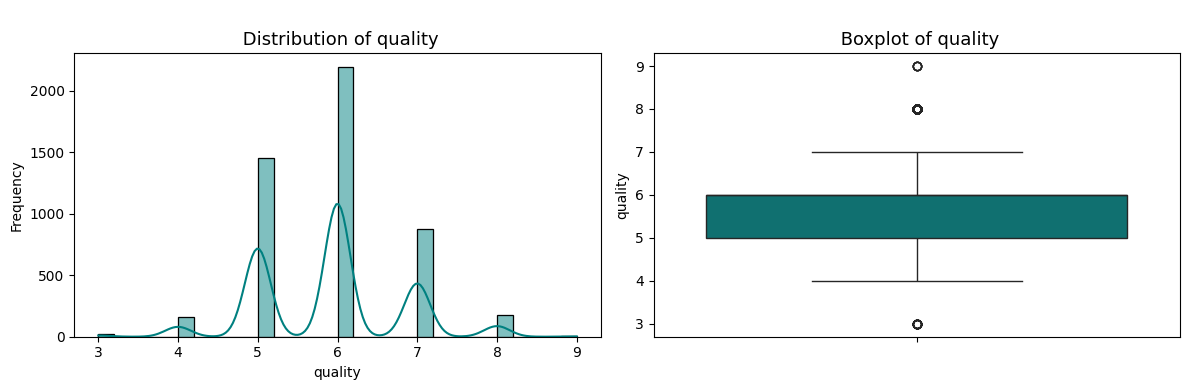

quality is fairly symmetric.


In [23]:
numeric_df = df.select_dtypes(include='number')
for column in numeric_df.columns:
    freq = df[column].value_counts(normalize=True) * 100
    print(freq)
    univariate_numeric(df,column)

In [24]:
white_wine.head(4)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,quality_label
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,Medium
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,Medium
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,Medium
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,Medium


In [25]:
def univariate_categorical(df,column):

    """
    Performs univariate EDA on a categorical ordinal column.
    Displays frequency table,  and a countplot.
    """

    print(f"Feature: {column}")
    print("="*40)

    # Frequency + Proportion 
    freq = df[column].value_counts()
    prop = df[column].value_counts(normalize=True)*100
    summary = pd.DataFrame({'Count':freq, 'Percentage': prop.round(2)})
    print(summary)
    print()

    #visualize 
    plt.figure(figsize=(8,5))
    ax=sns.countplot(x=column,data=df)
    plt.title(f'Distribution of {column}', fontsize=13)
    plt.xlabel(column)
    plt.ylabel('Count')


    #Annotate each bar with percentage
    total = len(df[column])
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2, height + 1,
                f'{(height/total)*100:.1f}%', ha='center')


Feature: quality_label
               Count  Percentage
quality_label                   
Medium          3655       74.62
High            1060       21.64
Low              183        3.74



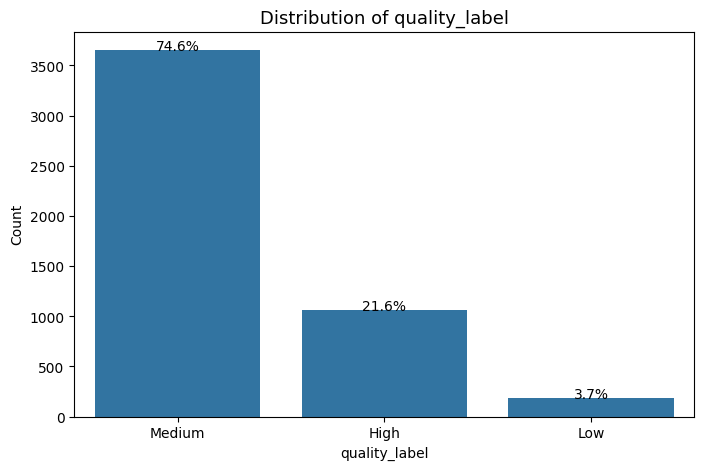

In [26]:
univariate_categorical(df,'quality_label')

----------------------------------------------------------------
 ### **2. Bivariate analysis**
 ---------------------------------------------------------------

In [27]:
# lets find the numerical features 
num_features = white_wine.select_dtypes(include=['int64','float64']).columns

# convert to dataframe
num_features =pd.DataFrame(white_wine[num_features])
num_features.head(2)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.001,3.0,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.994,3.3,0.49,9.5,6


**1. Numeric to Numeric**

Correlation with target

In [ ]:
# numeric_df = df.select_dtypes(include='number').copy()
# target_col = 'quality'
# if target_col not in numeric_df.columns:
#     raise ValueError(f'Target column {'quality'} must be numeric and present in the dataframe')

# # compute correlation of  every numeric column with the target
# corrs = numeric_df.corrwith(numeric_df[target_col]).drop(target_col)
# corrs_df = corrs.to_frame(name='corr').T # shape (1,n)

# plt.figure(figsize=(10,8))
# sns.heatmap(corrs_df,annot=True,
#             fmt=".3f",cmap="coolwarm",
#             center=0, vmin=1,vmax=1,cbar_kws={'orientation':'vertical','shrink':0.7})

# plt.xticks(rotation=45,ha='right')
# plt.yticks([0],[target_col],rotation=0)
# plt.title(f'Correlation of numeric features with {target_col}',fontsize=12)
# plt.tight_layout()
# plt.show()

# # return sorted correlations for downstream use
# corrs.reindex(corrs.abs().sort_values(ascending=False).index)



def correlation_with_target(df, target_col, figsize=(10,2)):
    """
    Plots a heatmap showing correlation of each numeric feature against target_col.
    Returns a Series of correlations (sorted by absolute magnitude).
    """
    # Keep only numeric columns
    numeric_df = df.select_dtypes(include='number').copy()
    if target_col not in numeric_df.columns:
        raise ValueError(f"Target column '{target_col}' must be numeric and present in the dataframe.")

    # compute correlations of every numeric column with the target
    corrs = numeric_df.corrwith(numeric_df[target_col]).drop(target_col)

    corrs_df = corrs.to_frame(name='corr').T  # shape (1, n)

    plt.figure(figsize=figsize)
    sns.heatmap(
        corrs_df,
        annot=True,
        fmt=".3f",
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        cbar_kws={'orientation': 'vertical', 'shrink':0.7}
    )
    plt.xticks(rotation=45, ha='right')
    plt.yticks([0], [target_col], rotation=0)
    plt.title(f'Correlation of numeric features with {target_col}', fontsize=12)
    plt.tight_layout()
    plt.show()

    # return sorted correlations for downstream use
    return corrs.reindex(corrs.abs().sort_values(ascending=False).index)


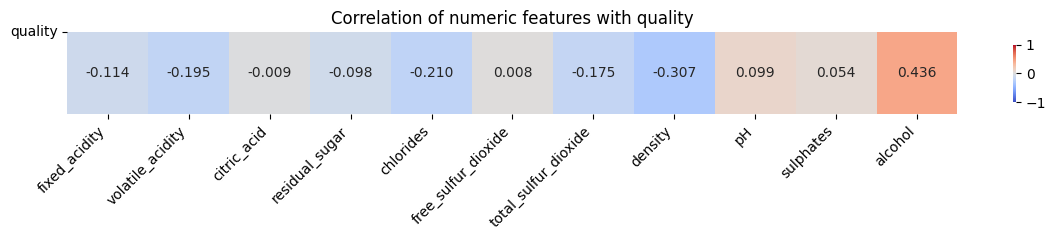

alcohol                 0.435575
density                -0.307123
chlorides              -0.209934
volatile_acidity       -0.194723
total_sulfur_dioxide   -0.174737
fixed_acidity          -0.113663
pH                      0.099427
residual_sugar         -0.097577
sulphates               0.053678
citric_acid            -0.009209
free_sulfur_dioxide     0.008158
dtype: float64


In [35]:
corr_series = correlation_with_target(df,'quality',figsize=(12,2.5))
print(corr_series)

In [ ]:
from scipy.stats import pearsonr
#the first graph was numeric-numeric using heatmap, this one is using regression line
def numeric_bivariate_plot(df, x_col, y_col):
    """
    Plots the relationship between two numeric variables with a regression line
    and displays the correlation coefficient.

    Parameters:
    -----------
    df : pandas.DataFrame
        Dataset containing the numeric columns
    x_col : str
        Name of the first numeric variable (x-axis)
    y_col : str
        Name of the second numeric variable (y-axis)
    """

    # Calculate correlation coefficient
    corr, p_value = pearsonr(df[x_col], df[y_col])

    # Create plot
    plt.figure(figsize=(8, 5))
    sns.regplot(data=df, x=x_col, y=y_col, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    
    # Title and labels
    plt.title(f"{y_col} vs {x_col}\nCorrelation: {corr:.3f} (p={p_value:.3f})", fontsize=13)
    plt.xlabel(x_col, fontsize=11)
    plt.ylabel(y_col, fontsize=11)
    plt.grid(alpha=0.3)
    plt.show()


In [36]:
numeric_df.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

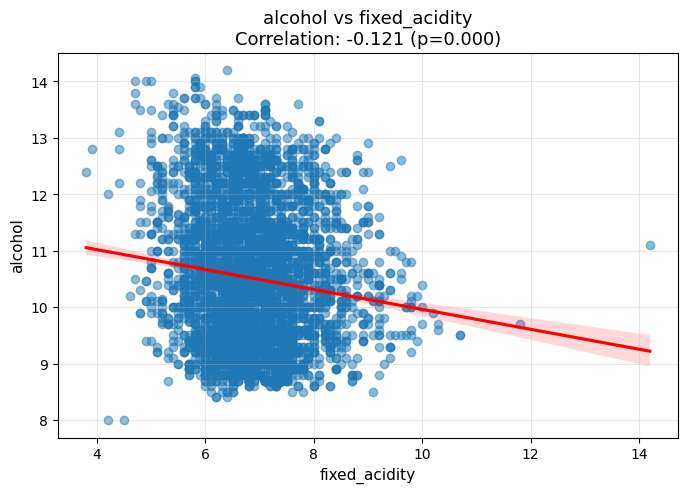

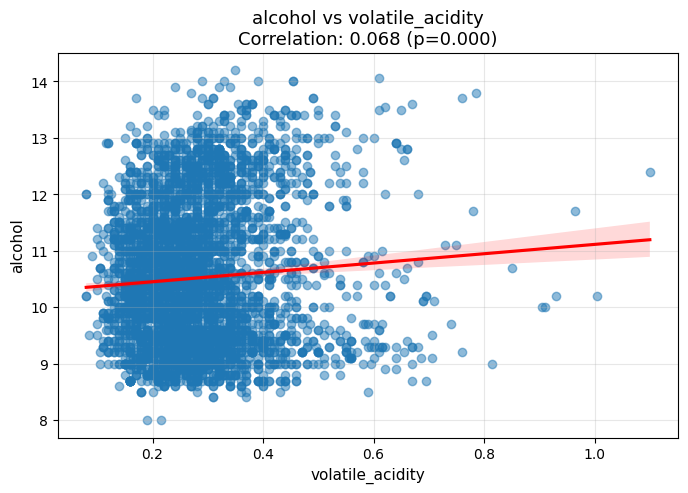

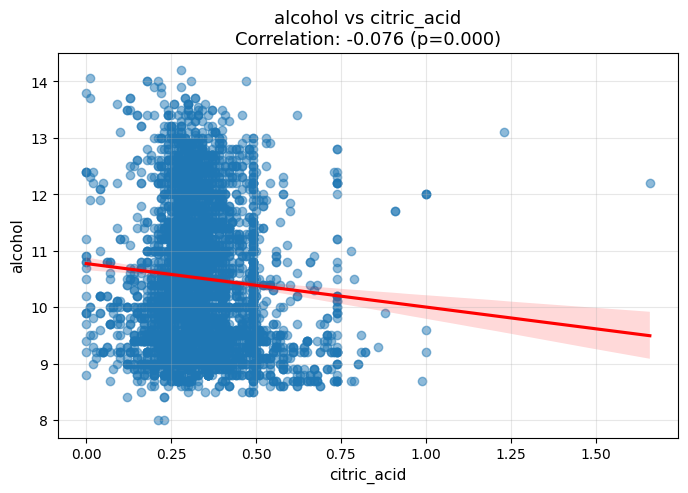

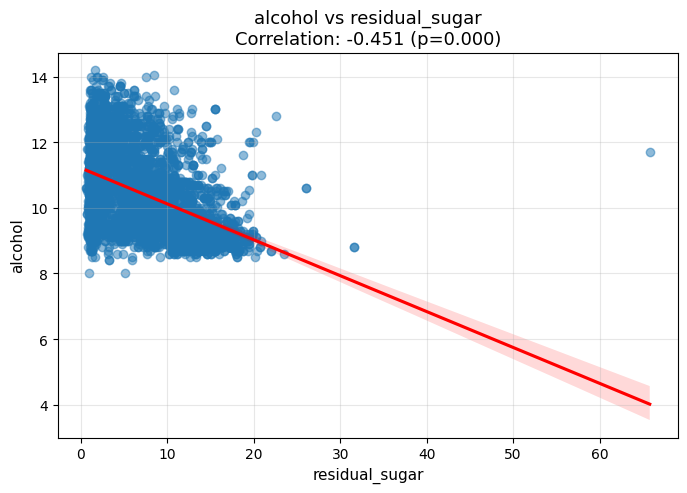

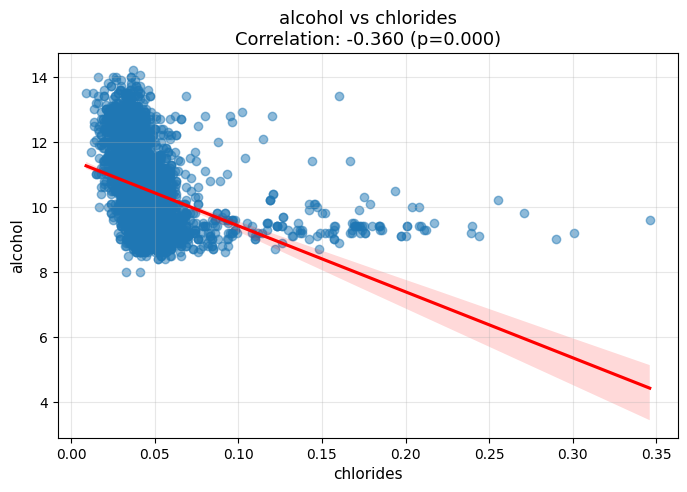

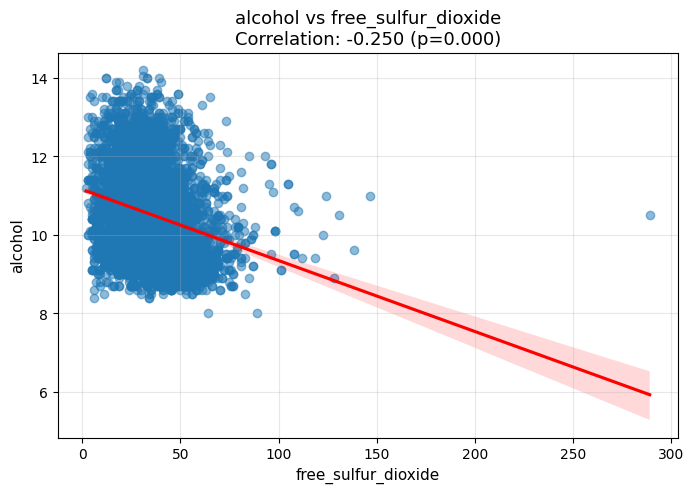

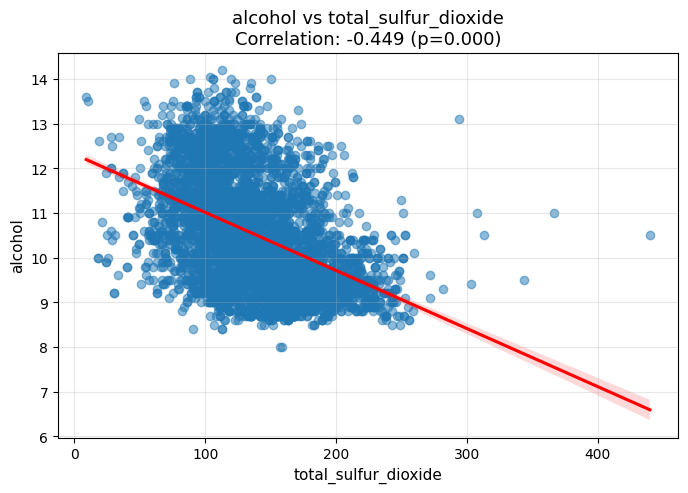

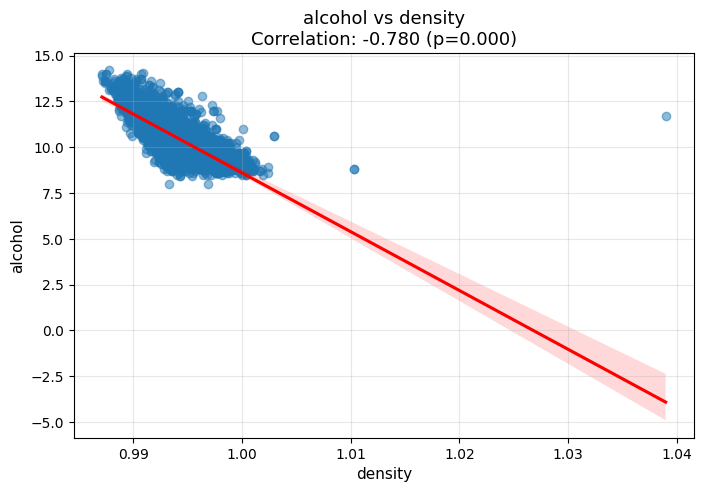

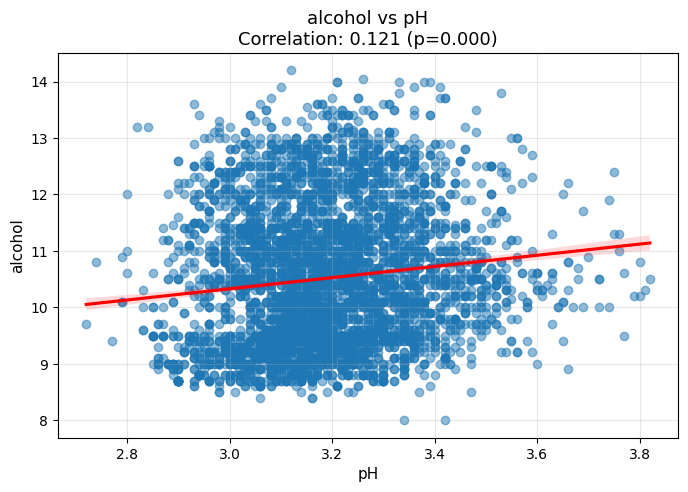

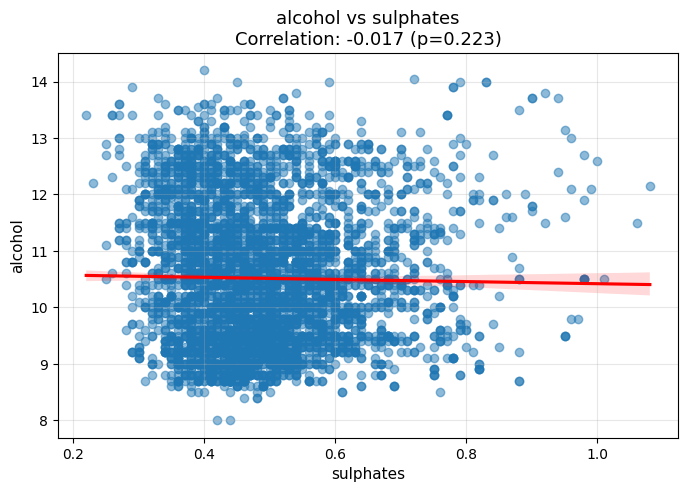

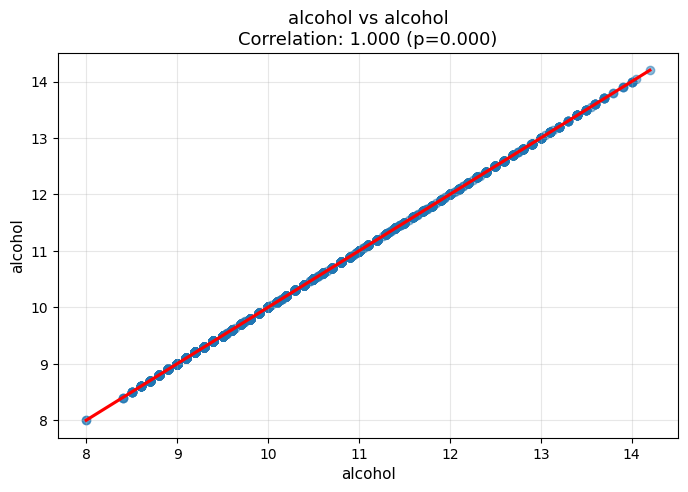

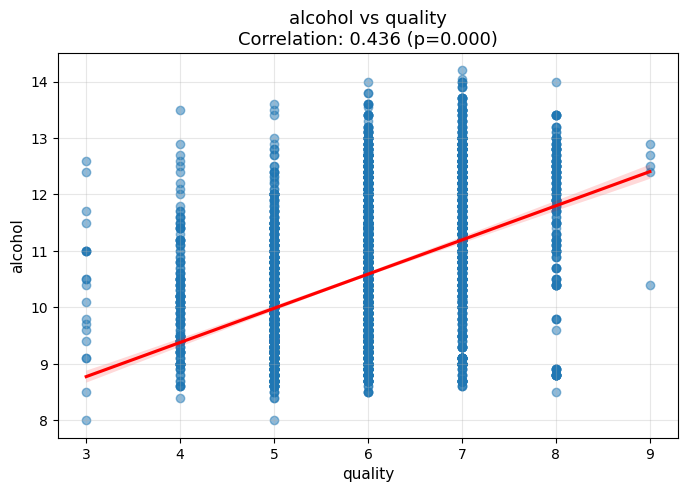

In [38]:
for x_col in numeric_df.columns:
    numeric_bivariate_plot(df,x_col,'alcohol')

In [47]:
def bivariate_num_cat(df,feature, target='quality_label'):
    """
    Plots and summarizes relationship between a numerical feature and a categorical target.
    """
    print(f" Feature: {feature} vs {target}")
    print("="*50)

    #group summary 
    summary = df.groupby(target)[feature].describe()[['mean','std','min','max']]
    print(summary)
    print()

    plt.figure(figsize=(12,8))
    plt.subplot(1,2,1)
    #boxplot +mean line
    sns.boxplot(x=target,y=feature,data=df,palette='Set2')
    plt.title(f'{feature} across {target} categories', fontsize=13)
    plt.xlabel(target)
    plt.ylabel(feature)
    plt.show()


    # Violin plot for distribution shape
    plt.subplot(1,2,2)
    sns.violinplot(x=target, y=feature, data=df, palette='Set3')
    plt.title(f'{feature} distribution by {target}', fontsize=13)
    plt.xlabel(target)
    plt.ylabel(feature)
    plt.show()



 Feature: fixed_acidity vs quality_label
                   mean       std  min   max
quality_label                               
High           6.725142  0.768798  3.9   9.2
Low            7.180874  1.171885  4.2  11.8
Medium         6.876060  0.839049  3.8  14.2



C:\Users\User\AppData\Local\Temp\ipykernel_14136\762470998.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target,y=feature,data=df,palette='Set2')


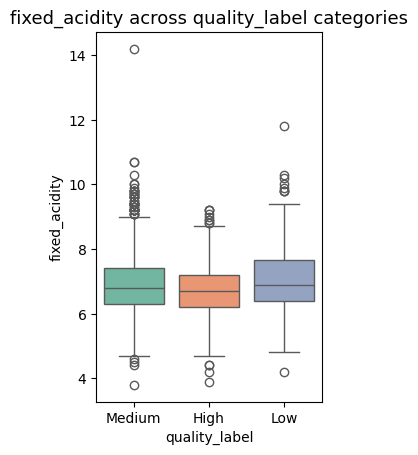

C:\Users\User\AppData\Local\Temp\ipykernel_14136\762470998.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target, y=feature, data=df, palette='Set3')


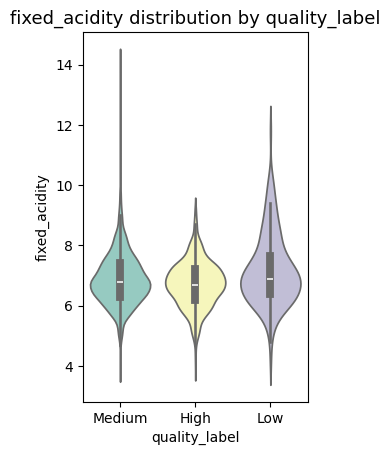

C:\Users\User\AppData\Local\Temp\ipykernel_14136\762470998.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target,y=feature,data=df,palette='Set2')


 Feature: volatile_acidity vs quality_label
                   mean       std   min    max
quality_label                                 
High           0.265349  0.094097  0.08  0.760
Low            0.375984  0.170525  0.11  1.100
Medium         0.277086  0.095253  0.08  0.965



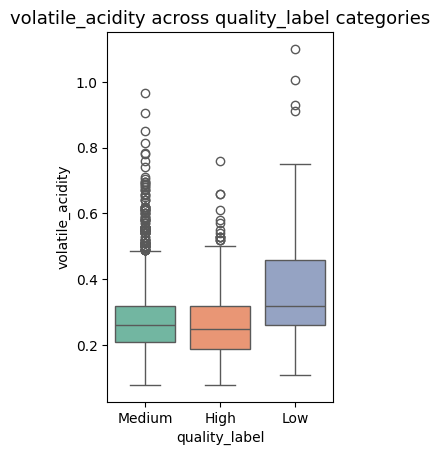

C:\Users\User\AppData\Local\Temp\ipykernel_14136\762470998.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target, y=feature, data=df, palette='Set3')


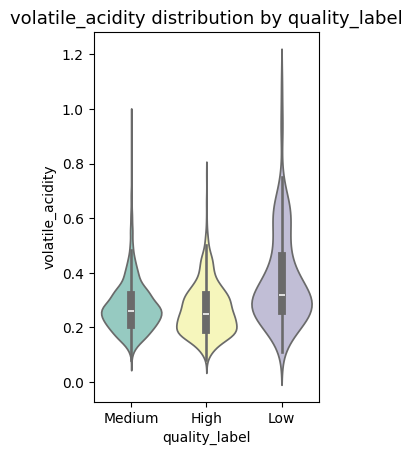

C:\Users\User\AppData\Local\Temp\ipykernel_14136\762470998.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target,y=feature,data=df,palette='Set2')


 Feature: citric_acid vs quality_label
                   mean       std   min   max
quality_label                                
High           0.326057  0.080288  0.01  0.74
Low            0.307705  0.157131  0.00  0.88
Medium         0.337877  0.128304  0.00  1.66



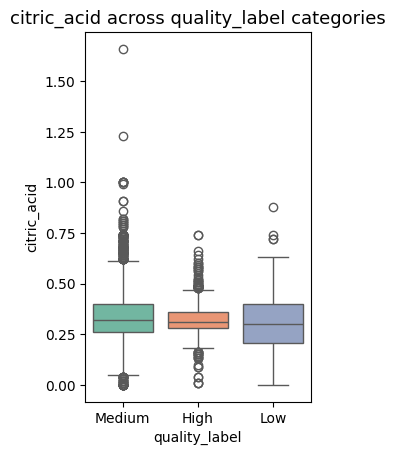

C:\Users\User\AppData\Local\Temp\ipykernel_14136\762470998.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target, y=feature, data=df, palette='Set3')


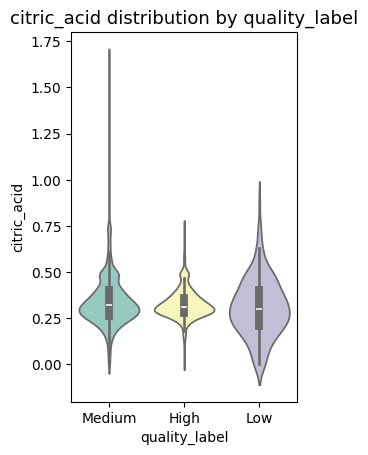

C:\Users\User\AppData\Local\Temp\ipykernel_14136\762470998.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target,y=feature,data=df,palette='Set2')


 Feature: residual_sugar vs quality_label
                   mean       std  min    max
quality_label                                
High           5.261509  4.290845  0.8  19.25
Low            4.821038  4.322845  0.7  17.55
Medium         6.797729  5.248933  0.6  65.80



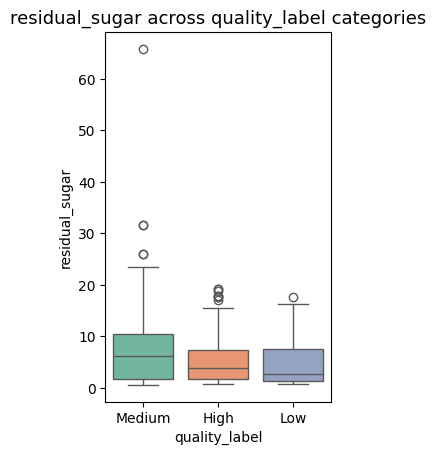

C:\Users\User\AppData\Local\Temp\ipykernel_14136\762470998.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target, y=feature, data=df, palette='Set3')


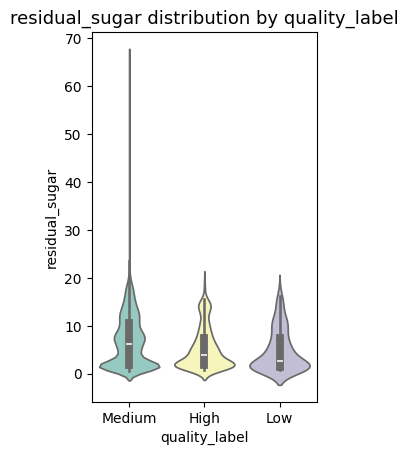

C:\Users\User\AppData\Local\Temp\ipykernel_14136\762470998.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target,y=feature,data=df,palette='Set2')


 Feature: chlorides vs quality_label
                   mean       std    min    max
quality_label                                  
High           0.038160  0.011145  0.012  0.135
Low            0.050557  0.028700  0.013  0.290
Medium         0.047740  0.023256  0.009  0.346



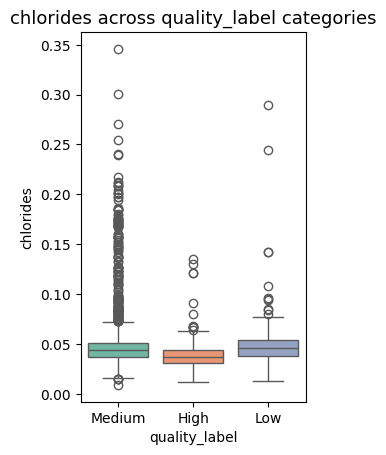

C:\Users\User\AppData\Local\Temp\ipykernel_14136\762470998.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target, y=feature, data=df, palette='Set3')


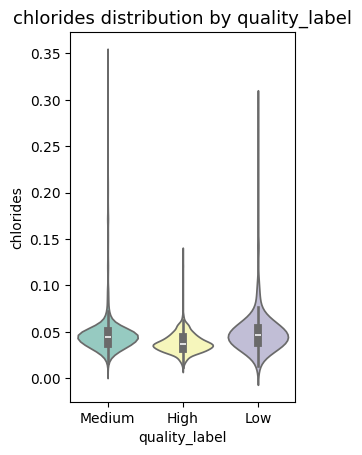

C:\Users\User\AppData\Local\Temp\ipykernel_14136\762470998.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target,y=feature,data=df,palette='Set2')


 Feature: free_sulfur_dioxide vs quality_label
                    mean        std  min    max
quality_label                                  
High           34.550472  13.797146  5.0  108.0
Low            26.633880  31.001858  3.0  289.0
Medium         35.962107  16.740109  2.0  131.0



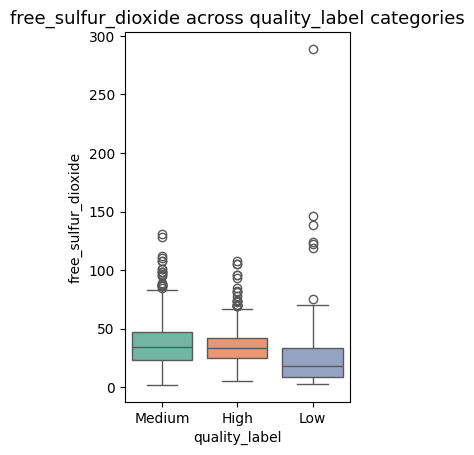

C:\Users\User\AppData\Local\Temp\ipykernel_14136\762470998.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target, y=feature, data=df, palette='Set3')


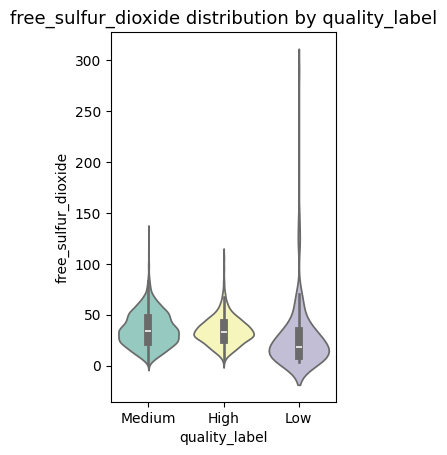

C:\Users\User\AppData\Local\Temp\ipykernel_14136\762470998.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target,y=feature,data=df,palette='Set2')


 Feature: total_sulfur_dioxide vs quality_label
                     mean        std   min    max
quality_label                                    
High           125.245283  32.724848  34.0  229.0
Low            130.232240  62.373163  10.0  440.0
Medium         142.571272  42.957893   9.0  344.0



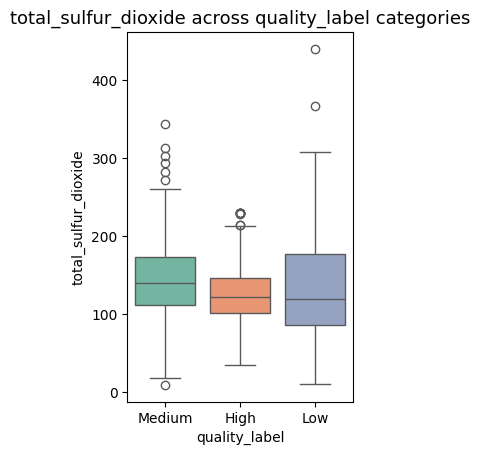

C:\Users\User\AppData\Local\Temp\ipykernel_14136\762470998.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target, y=feature, data=df, palette='Set3')


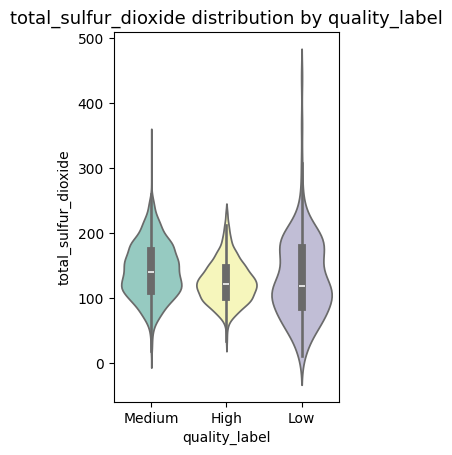

 Feature: density vs quality_label
                   mean       std      min      max
quality_label                                      
High           0.992412  0.002772  0.98711  1.00060
Low            0.994343  0.002504  0.98920  1.00040
Medium         0.994480  0.002913  0.98722  1.03898



C:\Users\User\AppData\Local\Temp\ipykernel_14136\762470998.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target,y=feature,data=df,palette='Set2')


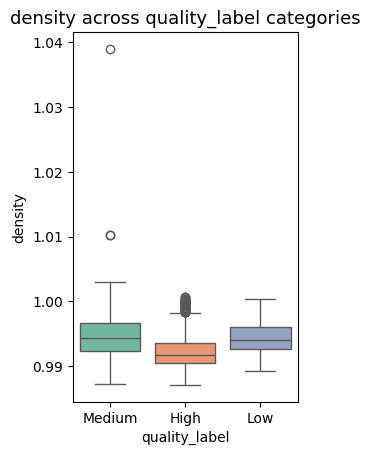

C:\Users\User\AppData\Local\Temp\ipykernel_14136\762470998.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target, y=feature, data=df, palette='Set3')


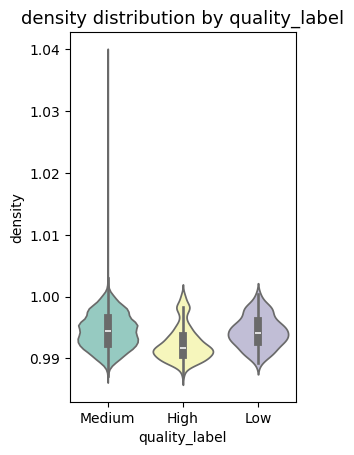

C:\Users\User\AppData\Local\Temp\ipykernel_14136\762470998.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target,y=feature,data=df,palette='Set2')


 Feature: pH vs quality_label
                   mean       std   min   max
quality_label                                
High           3.215132  0.157185  2.84  3.82
Low            3.183388  0.168668  2.83  3.72
Medium         3.180720  0.147352  2.72  3.81



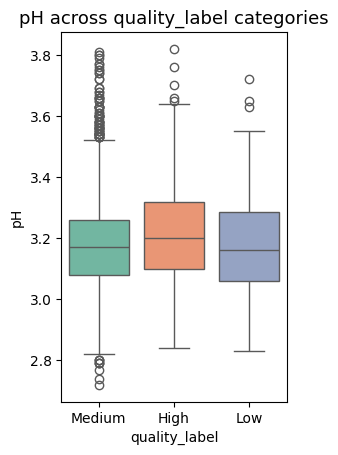

C:\Users\User\AppData\Local\Temp\ipykernel_14136\762470998.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target, y=feature, data=df, palette='Set3')


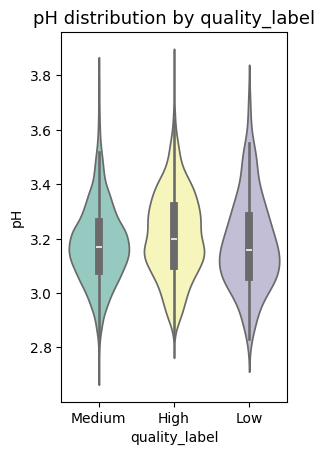

C:\Users\User\AppData\Local\Temp\ipykernel_14136\762470998.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target,y=feature,data=df,palette='Set2')


 Feature: sulphates vs quality_label
                   mean       std   min   max
quality_label                                
High           0.500142  0.133044  0.22  1.08
Low            0.475956  0.117847  0.25  0.87
Medium         0.487557  0.107647  0.23  1.06



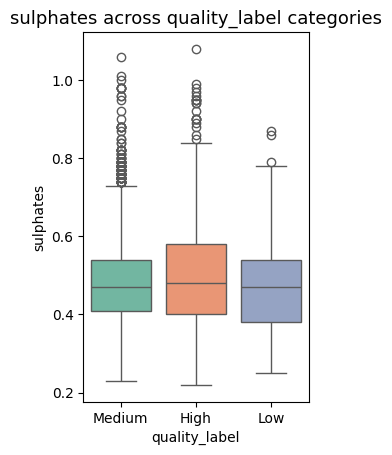

C:\Users\User\AppData\Local\Temp\ipykernel_14136\762470998.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target, y=feature, data=df, palette='Set3')


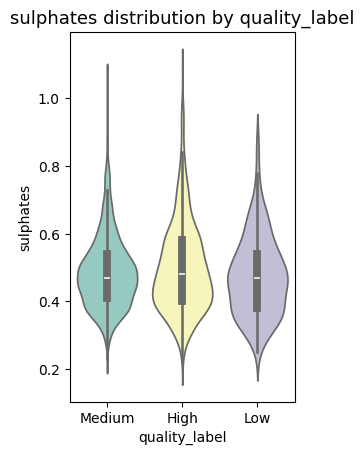

C:\Users\User\AppData\Local\Temp\ipykernel_14136\762470998.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target,y=feature,data=df,palette='Set2')


 Feature: alcohol vs quality_label
                    mean       std  min   max
quality_label                                
High           11.416022  1.255209  8.5  14.2
Low            10.173497  1.027570  8.0  13.5
Medium         10.269808  1.104035  8.0  14.0



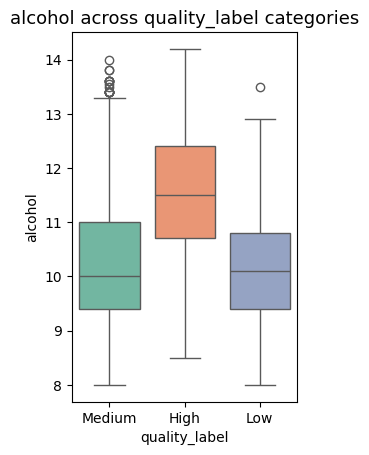

C:\Users\User\AppData\Local\Temp\ipykernel_14136\762470998.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target, y=feature, data=df, palette='Set3')


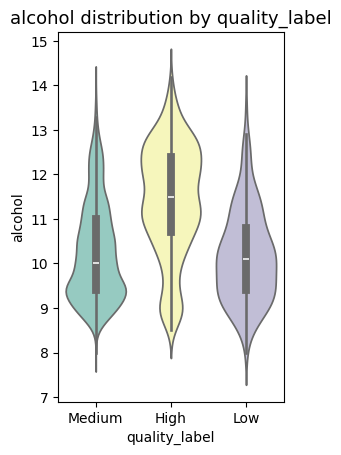

C:\Users\User\AppData\Local\Temp\ipykernel_14136\762470998.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target,y=feature,data=df,palette='Set2')


 Feature: quality vs quality_label
                   mean       std  min  max
quality_label                              
High           7.174528  0.391978  7.0  9.0
Low            3.890710  0.312858  3.0  4.0
Medium         5.601368  0.489684  5.0  6.0



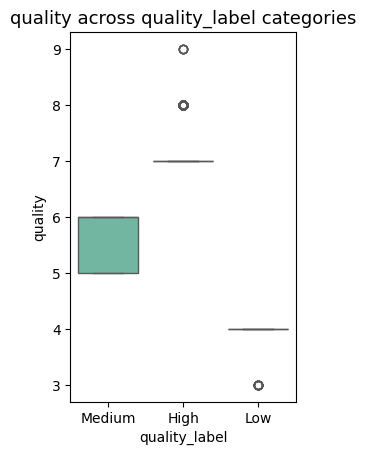

C:\Users\User\AppData\Local\Temp\ipykernel_14136\762470998.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target, y=feature, data=df, palette='Set3')


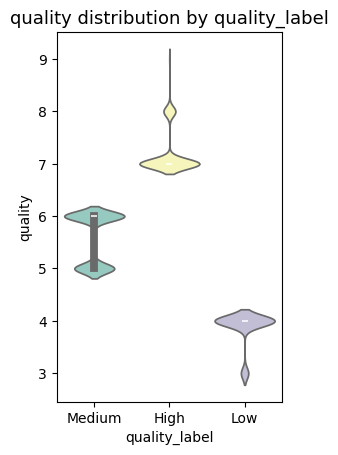

In [46]:
for col in num_features:
    bivariate_num_cat(white_wine, col, target='quality_label')

### **3. Trivariate analysis**

In [59]:
def trivariate_plot(df,x_col,y_col,hue_col):
    plt.figure(figsize=(8, 6))
    sns.lmplot(data=df,x=x_col,y=y_col,hue=hue_col,height=6,
            aspect=1.2,scatter_kws={'alpha':0.6},
            line_kws={'linewidth':2})
    plt.title(f"{y_col} vs {x_col} by {hue_col}", fontsize=13)
    plt.xlabel(x_col, fontsize=11)
    plt.ylabel(y_col, fontsize=11)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


<Figure size 800x600 with 0 Axes>

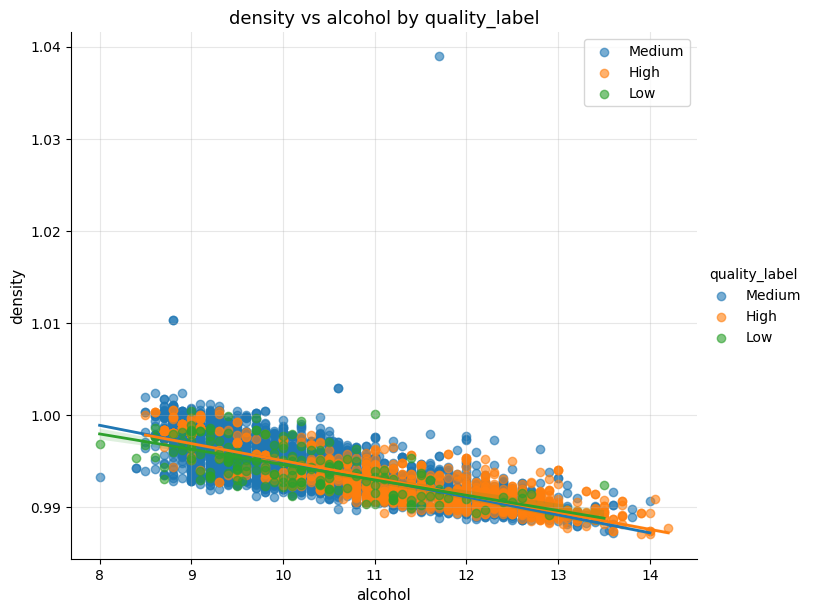

In [60]:
# Example: explore alcohol vs density by wine quality category
trivariate_plot(df, 'alcohol', 'density', 'quality_label')

In [30]:
# Suitable for variables with more than two categories without order
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    contingency_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_matrix)[0]
    n = np.sum(contingency_matrix.values)
    return np.sqrt(chi2 / (n * (min(contingency_matrix.shape)-1)))

cramers_v(df['Feature1'], df['Feature2'])




 Using Cramér’s V for Nominal Variables
Cramér’s V quantifies association based on a chi-square test from a contingency table. Value ranges from 0 (no association) to 1 (perfect association).
# Python 3
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Example function to compute Cramér's V
def cramers_v(x, y):
    contingency_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_matrix)[0]
    n = np.sum(contingency_matrix.values)
    return np.sqrt(chi2 / (n * (min(contingency_matrix.shape)-1)))

# Example usage
df = pd.DataFrame({
    'Feature1': ['A', 'B', 'A', 'C', 'B', 'A'],
    'Feature2': ['X', 'X', 'Y', 'Y', 'X', 'Y']
})

correlation = cramers_v(df['Feature1'], df['Feature2'])
print(f"Cramér's V: {correlation:.3f}")

IndentationError: unexpected indent (4115015255.py, line 17)

In [ ]:
# ordinal example
df['Feature1_ord'] = df['Feature1'].map({'Low':1,'Medium':2,'High':3})
df['Feature2_ord'] = df['Feature2'].map({'Low':1,'Medium':2,'High':3})
corr_spearman = df['Feature1_ord'].corr(df['Feature2_ord'], method='spearman')
print(f"Spearman correlation: {corr_spearman:.3f}")